In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv('dataforlang.csv')
df.sample(5)

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
15467,15831,3,0,3,0,1,RT @HennyHeathen: The fuuuck happened to her ?...
18334,18742,3,0,3,0,1,RT @_PlayboyG: Another movie that's gonna make...
15137,15495,3,2,1,0,0,RT @ExquiZiteBeauty: &#128584;&#128584;&#12858...
13206,13531,3,2,1,0,0,Naw RT @BakeGriffin Am I the only one mad that...
6184,6361,3,0,3,0,1,@italian_montana OUUUUUFFFFF you will see pussy


In [4]:
classes = ['Hate speech' , 'Offensive_language','None']

In [5]:
df.drop(['count','hate_speech','offensive_language','neither','Unnamed: 0'],axis=1,inplace=True)

In [6]:
df.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [7]:
df.shape

(24783, 2)

Hate speech  :  1430
Offensive_language  :  19190
None  :  4163


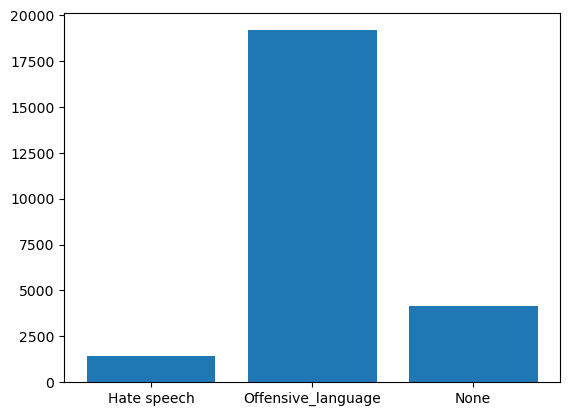

In [8]:
lable = df['class']
unique , counts = np.unique(lable,return_counts=True)
values = list(zip(unique,counts))
plt.bar(classes,counts)
for i in values:
    print(classes[i[0]],' : ', i[1])
plt.show()

In [9]:
hate_tweet = df[df['class']==0]
offensive_tweet = df[df['class']==1]
none = df[df['class']==2]
print(hate_tweet.shape)
print(offensive_tweet.shape) 
print(none.shape)

(1430, 2)
(19190, 2)
(4163, 2)


In [10]:
for i in range(3):
    hate_tweet = pd.concat([hate_tweet,hate_tweet],ignore_index=True)
none = pd.concat([none,none,none],ignore_index=True)
offensive_tweet = offensive_tweet.iloc[0:12000,:]
print(hate_tweet.shape)
print(offensive_tweet.shape)
print(none.shape)

(11440, 2)
(12000, 2)
(12489, 2)


In [11]:
df = pd.concat([hate_tweet,offensive_tweet,none],ignore_index=True)
df.shape

(35929, 2)

Hate speech  :  11440
Offensive_language  :  12000
None  :  12489


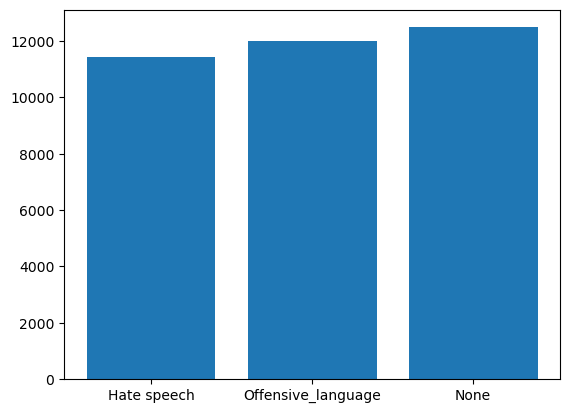

In [12]:
lable = df['class']
unique , counts = np.unique(lable,return_counts=True)
values = list(zip(unique,counts))
plt.bar(classes,counts)
for i in values:
    print(classes[i[0]],' : ', i[1])
plt.show()

In [13]:
df.head()

,class,tweet
0,0,"""@Blackman38Tide: @WhaleLookyHere @HowdyDowdy1..."
1,0,"""@CB_Baby24: @white_thunduh alsarabsss"" hes a ..."
2,0,"""@DevilGrimz: @VigxRArts you're fucking gay, b..."
3,0,"""@MarkRoundtreeJr: LMFAOOOO I HATE BLACK PEOPL..."
4,0,"""@NoChillPaz: ""At least I'm not a nigger"" http..."


Lemmatization helps group word variations into a common base, making text analysis cleaner.

Stopwords removal filters out very common, non-informative words.

Regular expressions (re) are useful to clean or structure your raw text data.

In [15]:
import nltk  ##Loads the nltk library, which is widely used for processing and analyzing human language data (text).
from nltk.stem import WordNetLemmatizer  #a tool that reduces words to their base or dictionary form (for example, “running” → “run”). This helps in standardizing words for analysis.
from nltk.corpus import stopwords # Imports the list of stopwords (common words like “and”, “the”, “is”, etc., which are often removed from text because they don’t add significant meaning).
import re # Loads the re module for using regular expressions (patterns to search or clean text).
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dkglt\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dkglt\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
# dealing with Slangs
d = {'luv':'love','wud':'would','lyk':'like','wateva':'whatever','ttyl':'talk to you later',
               'kul':'cool','fyn':'fine','omg':'oh my god!','fam':'family','bruh':'brother',
               'cud':'could','fud':'food', 'u': 'you', 
     'ur':'your', 'bday' : 'birthday', 'bihday' : 'birthday'}

In [17]:
stop_word = set(stopwords.words("english"))
stop_word.add('rt')
stop_word.remove('not')
lemmatizer = WordNetLemmatizer()

giant_url_regex = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
mention_regex = r'@[\w\-]+'


In [18]:
def clean_text(text):
    text = re.sub('""',"",text)
    text = re.sub(mention_regex,' ',text)
    text = re.sub(giant_url_regex,' ',text)
    text = text.lower()
    text = re.sub("hm+","",text)
    text = re.sub("[^a-z]+", " ", text)
    text = text.split()
    text = [word for word in text if not word in stop_word]
    text = [d[word] if word in d else word for word in text]  #replacing some slangs
    text = [lemmatizer.lemmatize(token) for token in text]
    text = [lemmatizer.lemmatize(token, "v") for token in text]
    text = " ".join(text)
    return text
    


In [19]:
df['processed_tweets'] = df.tweet.apply(lambda x: clean_text(x))   # df.review.map(clean_text) Also can be used
df.head()

,class,tweet,processed_tweets
0,0,"""@Blackman38Tide: @WhaleLookyHere @HowdyDowdy1...",queer gaywad
1,0,"""@CB_Baby24: @white_thunduh alsarabsss"" hes a ...",alsarabsss he beaner smh tell he mexican
2,0,"""@DevilGrimz: @VigxRArts you're fucking gay, b...",fuck gay blacklist hoe hold tehgodclan anyway
3,0,"""@MarkRoundtreeJr: LMFAOOOO I HATE BLACK PEOPL...",lmfaoooo hate black people black people nigger
4,0,"""@NoChillPaz: ""At least I'm not a nigger"" http...",least not nigger lmfao


In [42]:
x = df.processed_tweets
y = df['class']
print(x.shape)
print(y.shape)

(35929,)
(35929,)


In [54]:
## Finding unqiue words 
tweet_leng = []
for i in x:
    tweet_leng.append(len(i.split()))
print("The avg length tweet are : ",np.mean(tweet_leng))
print("The max length tweet are : ",np.max(tweet_leng))
print("The min length tweet are : ",np.min(tweet_leng))

The avg length tweet are :  7.669431378552145
The max length tweet are :  28
The min length tweet are :  0


In [64]:
tweets_length = pd.DataFrame(tweet_leng)
tweets_length.describe()

,0
count,35929.000000
mean,7.669431
std,3.989824
min,0.000000
25%,4.000000
50%,7.000000
75%,11.000000
max,28.000000


In [76]:
col = list(zip(unique,counts))
col = sorted(col, key = lambda x: x[1], reverse=True)
col = pd.DataFrame(col)
print("most occuring words are :")
col.iloc[:20,:]

most occuring words are :


,0,1
0,2,12489
1,1,12000
2,0,11440


In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [80]:
vect = TfidfVectorizer(max_features=8000)
vect.fit(x)

TfidfVectorizer(max_features=8000)

In [84]:
print(len(vect.vocabulary_))
print(vect.idf_.shape)

8000
(8000,)


In [86]:
x_tf = vect.transform(x).toarray()
print(x_tf.shape)

(35929, 8000)


In [92]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [99]:
num_words = 8000
emd = 32 
token = Tokenizer(num_words=num_words,oov_token="oov")
token.fit_on_texts(x)
word_index=token.word_index
sequences = token.texts_to_sequences(x)
length=[]
for i in sequences:
    length.append(len(i))
print(len(length))
print("Mean is: ",np.mean(length))
print("Max is: ",np.max(length))
print("Min is: ",np.min(length))

35929
Mean is:  7.669431378552145
Max is:  28
Min is:  0


In [110]:
pad_len = 24 
sequences = pad_sequences(sequences,maxlen = pad_len,truncating = 'pre', padding='post')
sequences.shape

(35929, 24)

In [114]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train,y_test = train_test_split(sequences,y,test_size=0.3,random_state=42)

In [118]:
x_train.shape
y_test.shape

(10779,)

In [120]:
from keras.layers import Dense, Embedding, Dropout , Activation, Flatten, SimpleRNN
from keras.layers import GlobalMaxPool1D
from keras.models import Model, Sequential
import tensorflow as tf

In [135]:
recall = tf.keras.metrics.Recall()
precision = tf.keras.metrics.Precision()

model = Sequential([Embedding(num_words, emd,input_shape=(pad_len,)),
                   SimpleRNN(8, return_sequences = True),
                   GlobalMaxPool1D(),
                   Dense(20,activation = 'relu',kernel_initializer='he_uniform'),
                   Dropout(0.25),
                   Dense(3,activation = 'softmax')])
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# model.name = 'Twitter Hate Text Classification'
model.summary()

C:\Users\dkglt\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 24, 32)         │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 24, 8)          │           328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ (None, 8)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,571 (1002.23 KB)

 Trainable params: 256,571 (1002.23 KB)

 Non-trainable params: 0 (0.00 B)

In [137]:
history = model.fit(x = x_train, y = y_train, epochs = 5,validation_split = 0.05)

Epoch 1/5
747/747 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.5604 - loss: 0.8628 - val_accuracy: 0.8498 - val_loss: 0.4335
Epoch 2/5
747/747 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8726 - loss: 0.3876 - val_accuracy: 0.9269 - val_loss: 0.2438
Epoch 3/5
747/747 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9422 - loss: 0.2021 - val_accuracy: 0.9483 - val_loss: 0.1811
Epoch 4/5
747/747 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9624 - loss: 0.1297 - val_accuracy: 0.9452 - val_loss: 0.1625
Epoch 5/5
747/747 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9740 - loss: 0.0958 - val_accuracy: 0.9563 - val_loss: 0.1555


In [139]:
evaluate = model.evaluate(x_test,y_test)

337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9465 - loss: 0.1828


In [141]:
print("Test Acuracy is : {:.2f} %".format(evaluate[1]*100))
print("Test Loss is : {:.4f}".format(evaluate[0]))

Test Acuracy is : 94.66 %
Test Loss is : 0.1812


In [143]:
predictions = model.predict(x_test)

337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [145]:
predict = []
for i in predictions:
    predict.append(np.argmax(i))

In [147]:
from sklearn import metrics
cm = metrics.confusion_matrix(predict,y_test)
acc = metrics.accuracy_score(predict,y_test)

In [149]:
print("The Confusion matrix is: \n",cm)

The Confusion matrix is: 
 [[3400  254   21]
 [  33 3218   76]
 [  11  181 3585]]


In [151]:
print(acc*100)

94.6562760924019


In [153]:
from sklearn import metrics
print(metrics.classification_report(y_test, predict))


              precision    recall  f1-score   support

           0       0.93      0.99      0.96      3444
           1       0.97      0.88      0.92      3653
           2       0.95      0.97      0.96      3682

    accuracy                           0.95     10779
   macro avg       0.95      0.95      0.95     10779
weighted avg       0.95      0.95      0.95     10779



### LSTM

In [168]:
from tensorflow.keras.layers import Embedding, LSTM, Dense
# ARCHITECTURE
EMBED_DIM = 32
LSTM_OUT = 64

model = Sequential()
model.add(Embedding(num_words, EMBED_DIM, input_shape=(pad_len,))),
model.add(LSTM(LSTM_OUT))
model.add(Dense(3, activation='softmax'))
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

print(model.summary())

C:\Users\dkglt\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 24, 32)         │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,027 (1.07 MB)

 Trainable params: 281,027 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

None


In [170]:
history = model.fit(x = x_train, y = y_train, epochs = 10,validation_split = 0.05)

Epoch 1/10
747/747 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.6524 - loss: 0.7082 - val_accuracy: 0.8919 - val_loss: 0.2907
Epoch 2/10
747/747 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9265 - loss: 0.2214 - val_accuracy: 0.9332 - val_loss: 0.2162
Epoch 3/10
747/747 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9519 - loss: 0.1553 - val_accuracy: 0.9269 - val_loss: 0.2336
Epoch 4/10
747/747 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9642 - loss: 0.1177 - val_accuracy: 0.9229 - val_loss: 0.2255
Epoch 5/10
747/747 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9664 - loss: 0.1089 - val_accuracy: 0.9340 - val_loss: 0.2183
Epoch 6/10
747/747 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9743 - loss: 0.0887 - val_accuracy: 0.9324 - val_loss: 0.2415
Epoch 7/10
747/747 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9746 - loss: 0.0842 - val_accuracy: 0.9420 - val_loss: 0.2192
Epoch 8/10
747/747 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9799 - loss: 0.0685 - 

In [172]:
evaluate = model.evaluate(x_test,y_test)

337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9382 - loss: 0.2529


In [174]:
print("Test Acuracy is : {:.2f} %".format(evaluate[1]*100))
print("Test Loss is : {:.4f}".format(evaluate[0]))

Test Acuracy is : 93.77 %
Test Loss is : 0.2570


In [176]:
predictions = model.predict(x_test)

337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


In [178]:
predict = []
for i in predictions:
    predict.append(np.argmax(i))

In [180]:
from sklearn import metrics
cm = metrics.confusion_matrix(predict,y_test)
acc = metrics.accuracy_score(predict,y_test)


In [182]:
print("The Confusion matrix is: \n",cm)

The Confusion matrix is: 
 [[3436  401   29]
 [   2 3077   58]
 [   6  175 3595]]


In [184]:
print(acc*100)

93.77493273958623


In [186]:
from sklearn import metrics
print(metrics.classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      3444
           1       0.98      0.84      0.91      3653
           2       0.95      0.98      0.96      3682

    accuracy                           0.94     10779
   macro avg       0.94      0.94      0.94     10779
weighted avg       0.94      0.94      0.94     10779

